In [171]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from TWA_skrf_Toolkit import TWA_skrf_Toolkit as rftoolkit
import skrf as rf
from scipy.optimize import minimize
import csv
import h5py

In [172]:
def point_delta_calculator(target, current):
    dx = target[0] - current[0]
    dy = target[1] - current[1]
    dz = target[2] - current[2]
    print(f'dx {dx}, dy {dy}, dz {dz}')

#point_delta_calculator(target=(0.0425, 0.1532, 0.6409375), current= (-0.3066, -0.003, -0.045))
point_delta_calculator(target=(0.0641, 0.0, -0.7672625+0.0027), current= (-0.627, 0.0, -0.8255) )
# point_delta_calculator(target=(0.0425, 0.1532, 0.6409375), current= (-0.3066, -0.0032, -0.045) )

# point_delta_calculator(target=(0.0025, 0.0034, 0), current=  (-0.04, -0.0016, -0.003))

# point_delta_calculator(target=(0.0475, 0.1614, -0.6040625) , current= (-0.0016, -0.003, 0.26))

# point_delta_calculator(target=(0.0425, 0.1532, -0.6090625) , current= (-0.3066, -0.0032, -0.045))

dx 0.6911, dy 0.0, dz 0.06093750000000009


In [174]:
num_straps = 9
f0 = 96e6
w0 = 2*np.pi*f0
clight = 3e8
Rant = 1.12 # m, hfs of d3d

n_par = -5 
k_par = w0*n_par/clight
print(f'k_par : {k_par} 1/m')
n_phi = Rant*k_par
print(f'n_phi: {n_phi}')


capz0 = 7.2194
antz0 = 50 # check that this is true
freqs_for_fullant = np.array([92, 93, 94, 95, 96, 97, 98, 99, 100])

# antenna files 
#capfile = 'S11_cap_scan_92_100_MHz_l_5cm_19cm.csv'
# capfile = 'S11_lab_cap_scan_92_100_MHz_l_3cm_19cm.csv'
capfile = 'S11_lab_with_spacer_cap_scan_92_100_MHz_l_3cm_19cm.csv'
#antfile = 'circ_model/fixed_exp_ant_test3.csv' 
# antfile = 'circ_model/fixed_exp_ant_lab1.csv'
antfile = 'circ_model/fixed_exp_ant_lab2.csv' # this one has the 3D printed spacers 
antfile = 'circ_model/fixed_lab3_5_55cmdvac.csv' # this one has the salt water tank in it, 5.55 cm away from antenna front (water face, not acrylic). 
myrfTWA = rftoolkit(num_straps=num_straps, f0=f0, k_par_max=k_par, capz0=capz0, 
                    antz0=antz0, freqs_for_fullant=freqs_for_fullant, capfile=capfile, antfile=antfile, center_fed_mode=True, de_embedded=False)

# add in only required geometry 
d = 15.625e-2
wstrap = 8e-2
myrfTWA.add_to_geometry('d', d)
myrfTWA.add_to_geometry('wstrap', wstrap)
myrfTWA.print_geometry()


k_par : -10.053096491487338 1/m
n_phi: -11.25946807046582
changes seeen
num_straps: 9
s_rez:      0.15625
lamda0:     3.1228381041666666
d:          0.15625
wstrap:     0.08


In [198]:
bounds = [(0.16, 0.18)] + [(0.03, 0.18)]*4 # [(0.05, 0.18)]*5 #[(0.02, 0.095)]*5
freq_bounds = (95,97)#(92, 100)
s11cutoff = -28#-35 # TODO this used to be -45 dB 
# new settings 
alpha = 10000#100e3#200000 # 10,000 worked well alpha1 move the peak
gamma = 6000#10e3#100000  alpha2 punish n|| = 0
lam1 = 0#1000#1000#10.017e6 # phase op alpha4
lam2 = 0#40e3#40000 # power ratio op alpha5
target_npar = 5.2#5.6 # TODO: change back to 5
target_PR = 2 # TODO: I do not know what the desired power ratio is. 
npar_bounds = [0, 10]
num_npars = 100
workers = 4

# secondary peak cancelation 
npar_secondary_peak_cancelation = np.linspace(0.88,3.111, 10)#np.append(np.linspace(0.88,3.111, 10), np.linspace(6,7.5, 10))
epsilon = 4000#15007.012 alpha3, secondary perak cancelation 


# --- Print Summary for Documentation ---
print("="*30)
print("RUN SETTINGS LOG")
print("="*30)
print(f"Bounds:         {bounds}")
print(f"Freq Bounds:    {freq_bounds}")
print(f"S11 Cutoff:     {s11cutoff} dB")
print(f"Alpha:          {alpha:,.0f}")
print(f"Gamma:          {gamma:,.0f}")
print(f"Lambda 1 & 2:   {lam1}, {lam2}")
print(f"Target n||:     {target_npar}")
print(f"Target PR:      {target_PR}")
print(f"Epsilon:        {epsilon:,.0f}")
print(f"Secondary Peak Cancellation Range:\n{npar_secondary_peak_cancelation}")
print("="*30)

res = myrfTWA.run_differential_evolution_global_op_npar_match_low_npar_zero_cancel_image_currents_reduce_secondary_peaks_S11_debug( 
                                            length_bounds=bounds,
                                            S11_db_cutouff=s11cutoff,
                                            freq=96e6, # in Hz
                                            freq_bounds=freq_bounds,
                                            alpha_npar_op=alpha,
                                            gamma_npar_op=gamma,
                                            target_npar=target_npar,
                                            npar_bounds=npar_bounds, # for finding the maximum for the optimization 
                                            num_npars=num_npars,
                                            lam1_image_current_phase_op=lam1,
                                            lam2_image_current_mag_op=lam2,
                                            target_power_ratio_image_current_op=target_PR,
                                            npar_array_secondary_peak_cancelation=npar_secondary_peak_cancelation,
                                            epsilon_secondary_peak_cancelation=epsilon,
                                            strategy='best1bin',
                                            symetric_mode=True,
                                            one_cap_type_mode=False,
                                            end_cap_mode=False,
                                            workers=workers)

RUN SETTINGS LOG
Bounds:         [(0.16, 0.18), (0.03, 0.18), (0.03, 0.18), (0.03, 0.18), (0.03, 0.18)]
Freq Bounds:    (95, 97)
S11 Cutoff:     -28 dB
Alpha:          10,000
Gamma:          6,000
Lambda 1 & 2:   0, 0
Target n||:     5.2
Target PR:      2
Epsilon:        4,000
Secondary Peak Cancellation Range:
[0.88       1.12788889 1.37577778 1.62366667 1.87155556 2.11944444
 2.36733333 2.61522222 2.86311111 3.111     ]
----------------------------------------
i_iter = 1
New simulation.
Point is: [0.17449057 0.04362815 0.0683674  0.14422867 0.09260199]
Average absolute error is : 4.97e+02
----------------------------------------
i_iter = 2
New simulation.
Point is: [0.17449058 0.04362815 0.0683674  0.14422867 0.09260199]
Average absolute error is : 4.97e+02
----------------------------------------
i_iter = 3
New simulation.
Point is: [0.17449057 0.04362816 0.0683674  0.14422867 0.09260199]
Average absolute error is : 4.97e+02
----------------------------------------
i_iter = 4
New si

In [199]:
lengths_found = res.x.tolist()
print('final lengths:', lengths_found)

final lengths: [0.17450474976612984, 0.04352561514791961, 0.068367033290636, 0.14454914159560228, 0.09242597017970902]


In [ ]:
# storage 

# case S1 final lengths: [0.1751118681442514, 0.04424840278184684, 0.06820956526447788, 0.14425285639665486, 0.09245496369970356]
# case **:) lengths_found = [0.17921633438007195, 
#                  0.057259043595802785, 
#                  0.06338864439835754, 
#                  0.13124789728914518, 
#                  0.09155353975410226]

# case s2 final lengths: [0.17450474976612984, 0.04352561514791961, 0.068367033290636, 0.14454914159560228, 0.09242597017970902]



In [195]:
# This is the vacuum optimized **:) run. 
# end_dy = -.13
# mid_dy = 0/1000
# feed_dy = 0/1000
# lengths_found = [0.17921633438007195 + end_dy, 
#                  0.057259043595802785+mid_dy, 
#                  0.06338864439835754+mid_dy, 
#                  0.13124789728914518+mid_dy, 
#                  0.09155353975410226+feed_dy]

final lengths: [0.17450474976612984, 0.04352561514791961, 0.068367033290636, 0.14454914159560228, 0.09242597017970902]


Text(0.5, 0.98, 'lengths: [0.17450474976612984, 0.04352561514791961, 0.068367033290636, 0.14454914159560228, 0.09242597017970902]')

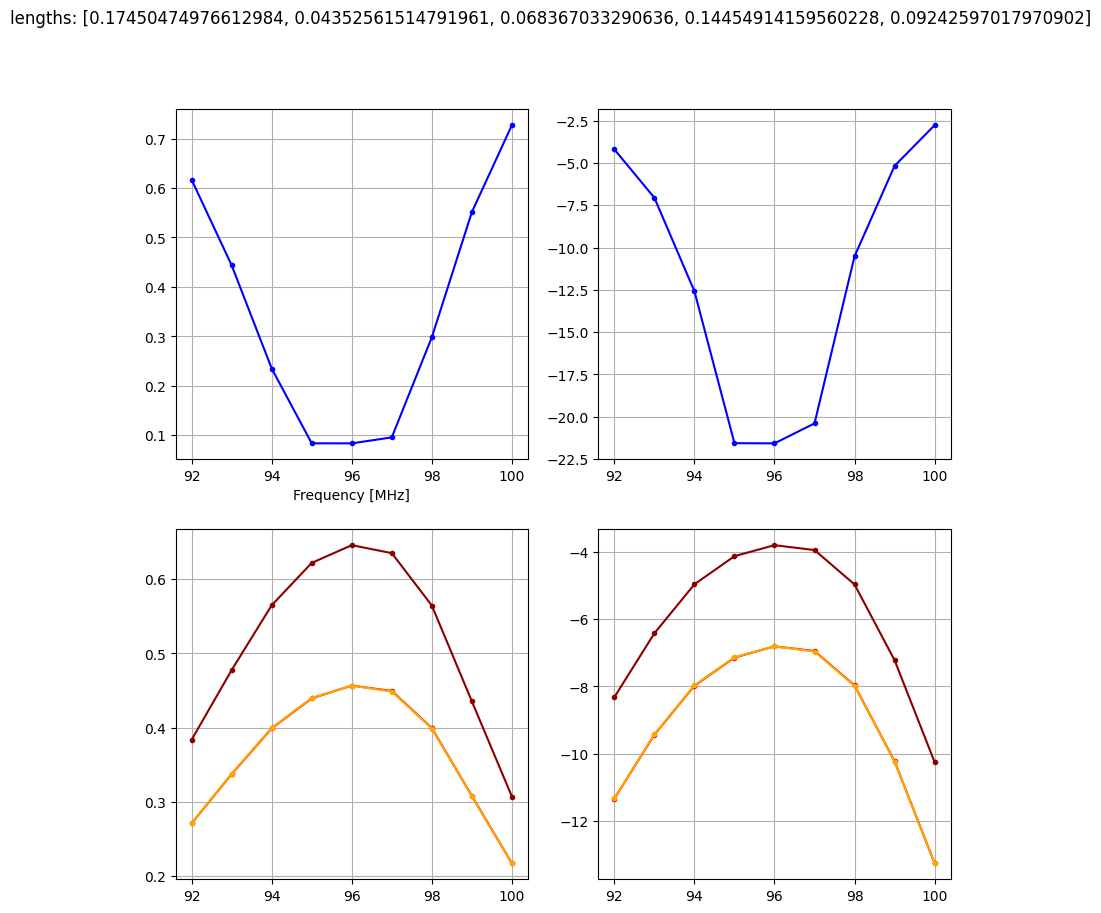

In [200]:
print('final lengths:',lengths_found)
full_net_optimized = myrfTWA.get_fullant_given_lengths_from_internal_datatable(lengths_found.copy(), symetric_mode=True) #TODO: make true

S11_array = np.zeros_like(myrfTWA.freqs_for_fullant, dtype='complex')
S21_array = np.zeros_like(myrfTWA.freqs_for_fullant, dtype='complex')
S31_array = np.zeros_like(myrfTWA.freqs_for_fullant, dtype='complex')

for i in range(S11_array.shape[0]):
    S11, S21, S31 = myrfTWA.get_full_TWA_network_S11_S21(fullnet=full_net_optimized, f=myrfTWA.freqs_for_fullant[i])
    S11_array[i] = S11
    S21_array[i] = S21
    S31_array[i] = S31

S11_mag_array = np.zeros_like(S11_array)
S11_db_array = np.zeros_like(S11_array)

S21_mag_array = np.zeros_like(S11_array)
S21_db_array = np.zeros_like(S11_array)

S31_mag_array = np.zeros_like(S11_array)
S31_db_array = np.zeros_like(S11_array)


for i in range(S11_array.shape[0]):
    S11_mag_array[i] = np.abs(S11_array[i])
    S11_db_array[i] = 20*np.log10(S11_mag_array[i])
    S21_mag_array[i] = np.abs(S21_array[i])
    S21_db_array[i] = 20*np.log10(S21_mag_array[i])
    S31_mag_array[i] = np.abs(S31_array[i])
    S31_db_array[i] = 20*np.log10(S31_mag_array[i])

fig, ax = plt.subplots(2,2,figsize=(10,10))

Strans_mag = np.sqrt(S31_mag_array**2 + S21_mag_array**2)
Strans_db = 20*np.log10(Strans_mag)

ax[0,0].plot(myrfTWA.freqs_for_fullant, S11_mag_array, marker='.', color='blue')
ax[0,0].set_xlabel('Frequency [MHz]')
ax[0,1].plot(myrfTWA.freqs_for_fullant, S11_db_array, marker='.', color='blue')
ax[0,0].grid()
ax[0,1].grid()
ax[1,0].plot(myrfTWA.freqs_for_fullant, S21_mag_array, marker='.', color='red')
ax[1,1].plot(myrfTWA.freqs_for_fullant, S21_db_array, marker='.', color='red')
ax[1,0].plot(myrfTWA.freqs_for_fullant, S31_mag_array, marker='.', color='orange')
ax[1,1].plot(myrfTWA.freqs_for_fullant, S31_db_array, marker='.', color='orange')
ax[1,0].plot(myrfTWA.freqs_for_fullant, Strans_mag, marker='.', color='darkred')
ax[1,1].plot(myrfTWA.freqs_for_fullant, Strans_db, marker='.', color='darkred')
ax[1,0].grid()
ax[1,1].grid()

fig.suptitle(f'lengths: {lengths_found}')

port indicies [1, 3, 5]
[ 0.14342505+0.06834173j -0.14342505-0.06834173j -0.04044563-0.0540021j
  0.04044563+0.0540021j  -0.0405534 -0.05405705j  0.0405534 +0.05405705j
 -0.1132713 -0.04288803j  0.1132713 +0.04288803j  0.10015277+0.03103096j
 -0.10015277-0.03103096j  0.34086406+0.19155463j -0.34086406-0.19155463j
  0.01022801+0.22192566j -0.01022801-0.22192566j -0.52900572-0.70646443j
  0.52900572+0.70646443j  0.0096223 +0.22198766j -0.0096223 -0.22198766j
  0.3414538 +0.19139153j -0.3414538 -0.19139153j  0.10033188+0.03095182j
 -0.10033188-0.03095182j -0.11346788-0.04280546j  0.11346788+0.04280546j]
--
[ 0.08631755-0.12453038j -0.07749645+0.12727704j -0.36167462+0.36476005j
  0.00208636-0.41043686j  0.53903798+0.37183289j  0.00127817-0.41116785j
 -0.36017097+0.36564541j -0.07702335+0.12748463j  0.08585337-0.12475335j]
[-55.27244583 121.33640111 134.75664533 -89.7087528   34.59823491
 -89.82188849 134.56785724 121.13942806 -55.46484046]
Strap powers shape: (9,)
[-0.30706914  0.67409112

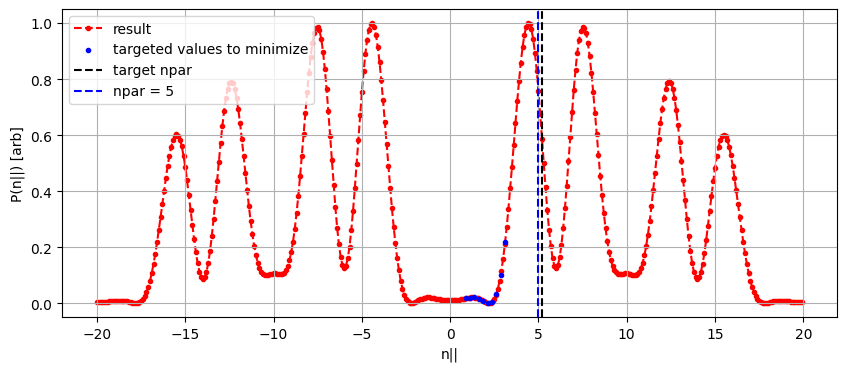

In [201]:
full_circ = myrfTWA.get_fullant_given_lengths_from_internal_datatable(lengths_found.copy(), symetric_mode=True,
                                                          one_cap_type_mode=False,
                                                          end_cap_mode=False,
                                                          return_circ=True)

power = [1, 0,0] # power excitation at the two ports 
phase = [0, 0,0 ] # radians 
print('port indicies', full_circ.port_indexes)
print(full_circ.currents(power,phase)[1,:])
print('--')
freq = 96e6
idx = np.where(full_circ.frequency.f_scaled == freq/1e6)
strap_current_array = full_circ.currents(power,phase)[idx,:].reshape(myrfTWA.num_straps + 3,2)[:,1][3:]  # remove double counting, remove two external ports 
print(strap_current_array)
# for now, use second row. 

def get_phase(complexn):
    real = np.real(complexn)
    imag = np.imag(complexn)
    angle_rad = np.arctan2(imag, real)
    return angle_rad
strap_phases = get_phase(strap_current_array)
strap_powers = np.abs(strap_current_array)**2
print(strap_phases*180/np.pi)
print(f'Strap powers shape: {strap_powers.shape}')

npar_array = np.arange(0, 10, .1)
npar_array = np.arange(-20, 20, .1)
print(strap_phases/(np.pi))

result_circ_model = np.array([], dtype='complex')
for i in range(npar_array.shape[0]):
    power = myrfTWA.analytic_power_spectrum_general_phase_diff(npar_array[i], w_strap=myrfTWA.geometry_dict['wstrap'],
                                                                d_strap=myrfTWA.geometry_dict['d'],
                                                                freq=freq,
                                                                phase_array=strap_phases,
                                                                )
    result_circ_model = np.append(result_circ_model, power)

result_circ_model_secondary_peak = np.array([], dtype='complex')
for i in range(npar_secondary_peak_cancelation.shape[0]):
    power = myrfTWA.analytic_power_spectrum_general_phase_diff(npar_secondary_peak_cancelation[i], w_strap=myrfTWA.geometry_dict['wstrap'],
                                                                d_strap=myrfTWA.geometry_dict['d'],
                                                                freq=freq,
                                                                phase_array=strap_phases,
                                                                )
    result_circ_model_secondary_peak = np.append(result_circ_model_secondary_peak, power)

plt.figure(figsize=(10,4))
plt.grid()
plt.plot(npar_array, np.real(result_circ_model)/np.max(np.real(result_circ_model)), color='red', linestyle='--', 
         label='result', marker='.', zorder=1)
plt.scatter(npar_secondary_peak_cancelation, result_circ_model_secondary_peak/np.max(np.real(result_circ_model)), 
            color='blue', marker='.', label='targeted values to minimize', zorder=2)
#plt.plot(npar_array, np.real(result_circ_model)/np.max(np.real(result_circ_model)), color='purple', linestyle='--', label='shifted')
plt.xlabel('n||')
plt.ylabel('P(n||) [arb]')

plt.axvline(x=target_npar, ymin=0, ymax=1, color='k', linestyle='--', label='target npar')
plt.axvline(x=5, ymin=0, ymax=1, color='blue', linestyle='--', label='npar = 5')
plt.legend()

print('npar_secondary_peak_cancelation', npar_secondary_peak_cancelation)